![Astrofisica Computacional](../../new_logo.png)

# Computational Astrophysics
## Retake: Python para el curso

## Dr. rer. nat. Jose Ivan Campos Rozo<sup>1,2</sup>

1. Hvar Observatory\
    Faculty of Geodesy, University of Zagreb\
    Zagreb, Croatia

2. Observatorio Astronómico Nacional\
   Facultad de Ciencias\
   Universidad Nacional de Colombia

e-mail: jicamposr@unal.edu.co & jcamposro@geof.hr)

---

### About this notebook

Este no es un tutorial de estas librerías: es un recorrido rápido para recordar qué existe, para qué sirve en astrofísica computacional, y dónde encontrar la documentación. Se asume que ya programan en Python.

---

## ¿Qué vamos a repasar?

* **NumPy** — arreglos y álgebra lineal
* **SciPy** — integración, optimización, EDOs, interpolación
* **Matplotlib** — visualización
* **Astropy** — unidades, constantes, coordenadas, tablas
* **SunPy** — datos de física solar
* Funciones, clases y lectura/escritura de archivos: las bases que ya conocen

## NumPy

* El arreglo `ndarray` es la base de *todo* el cómputo numérico en Python
* Operaciones vectorizadas: mucho más rápidas que loops explícitos
* Base sobre la que están construidas SciPy, Matplotlib, Astropy...

In [1]:
import numpy as np

t = np.linspace(0, 10, 100)          # arreglo de tiempos
flujo = np.exp(-((t - 5)**2) / 2)  # curva de luz sintetica (gaussiana)

print(t[0:5])
print(flujo[0:5])
print('maximo:', flujo.max(), 'en t =', t[flujo.argmax()])

[0.        0.1010101 0.2020202 0.3030303 0.4040404]
[3.72665317e-06 6.14389891e-06 1.00262383e-05 1.61957424e-05
 2.58959932e-05]
maximo: 0.9987254328882499 en t = 4.94949494949495


## SciPy

* Construida sobre NumPy: algoritmos numéricos ya implementados y optimizados
* `scipy.integrate` — integración numérica y solución de EDOs
* `scipy.optimize` — raíces, mínimos, ajuste de curvas
* `scipy.interpolate` — interpolación
* Usaremos estos módulos extensamente en la Parte 1 y 2 del curso

In [2]:
from scipy import integrate, optimize

# Integrar una funcion (ej. luminosidad acumulada)
f = lambda x: np.exp(-x**2)
resultado, error_est = integrate.quad(f, 0, np.inf)
print('integral =', resultado, '  error estimado =', error_est)

# Encontrar una raiz (ej. tiempo en que una señal cruza un umbral)
raiz = optimize.brentq(lambda x: np.cos(x) - x, 0, 1)
print('raiz =', raiz)

integral = 0.8862269254527579   error estimado = 7.10131839047246e-09
raiz = 0.7390851332151559


## Matplotlib

* La librería de visualización estándar del ecosistema científico de Python
* `plt.plot`, `plt.scatter`, `plt.imshow`, subplots, etc.
* Astropy y SunPy generan objetos que se visualizan directamente con Matplotlib

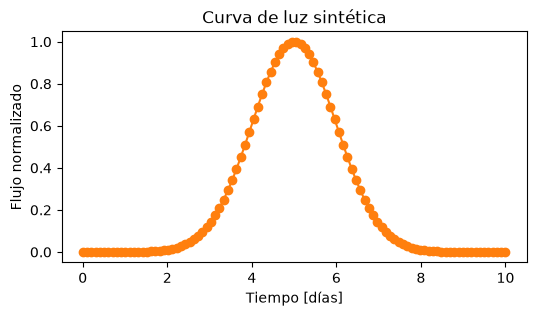

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t, flujo, 'o-', color='tab:orange')
ax.set_xlabel('Tiempo [días]')
ax.set_ylabel('Flujo normalizado')
ax.set_title('Curva de luz sintética')
plt.show()

## Astropy

* El paquete central de astronomía en Python (proyecto de la comunidad, no de una sola institución)
* `astropy.units` — cantidades físicas con unidades explícitas
* `astropy.constants` — constantes físicas y astronómicas
* `astropy.coordinates` — sistemas de coordenadas celestes
* `astropy.table`, `astropy.io.fits` — tablas y archivos FITS

In [4]:
import astropy.units as u
from astropy import constants as const

masa_sol = 1.0 * u.Msun
radio_sol = 1.0 * const.R_sun

densidad = (masa_sol / (4/3 * np.pi * radio_sol**3)).to(u.g / u.cm**3)
print('densidad media del Sol:', densidad)

densidad media del Sol: 1.4097798243075257 g / cm3


In [5]:
from astropy.coordinates import SkyCoord

betelgeuse = SkyCoord.from_name('Betelgeuse')  # requiere conexion a internet
print(betelgeuse.ra, betelgeuse.dec)

88d47m34.580364s 7d24m25.4304s


## SunPy

* Paquete de la comunidad para física solar (construido sobre Astropy)
* `sunpy.map.Map` — imágenes solares (SDO/AIA, etc.) con metadatos de observación
* `sunpy.net.Fido` — búsqueda y descarga de datos solares
* Lo usaremos en el bloque de análisis de datos más adelante en el curso

/home/alejo/mi_entorno/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Files Downloaded:   0%|                                                                  | 0/1 [00:00<?, ?file/s]
AIA20110607_063302_0171_lowres.fits:   0%|                                            | 0.00/973k [00:00<?, ?B/s]
AIA20110607_063302_0171_lowres.fits:   0%|                                   | 1.02k/973k [00:00<02:53, 5.62kB/s]
AIA20110607_063302_0171_lowres.fits:  20%|███████▍                             | 196k/973k [00:00<00:01, 703kB/s]
AIA20110607_063302_0171_lowres.fits:  85%|██████████████████████████████▌     | 826k/973k [00:00<00:00, 2.60MB/s]
Files Downloaded: 100%|██████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.04s/file]


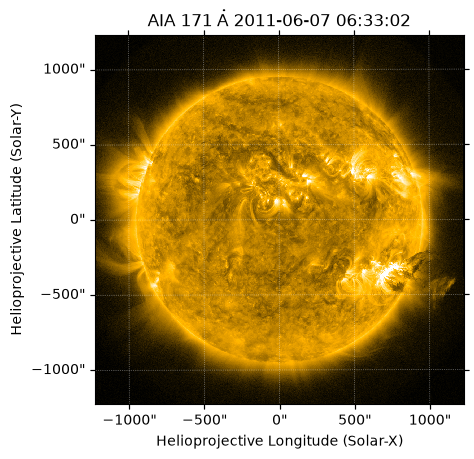

In [6]:
import sunpy.map
import sunpy.data.sample  # descarga datos de ejemplo (requiere internet)

mapa = sunpy.map.Map(sunpy.data.sample.AIA_171_IMAGE)

fig = plt.figure()
ax = fig.add_subplot(projection=mapa)
#mapa.plot(axes=ax)
mapa.plot(axes=ax,clip_interval=(1, 99.9)*u.percent)
plt.show()

## Funciones, clases y archivos

* Organizaremos casi todo el código del curso en **funciones** y, cuando aplique, **clases**
* Lectura/escritura de datos: `np.loadtxt` / `np.savetxt` para texto plano,
* `astropy.io.fits` para FITS, `astropy.table` / `pandas` para tablas

In [7]:
def energia_cinetica(masa, velocidad):
    """Energia cinetica no relativista."""
    return 0.5 * masa * velocidad**2

class Particula:
    def __init__(self, masa, posicion, velocidad):
        self.masa = masa
        self.posicion = np.array(posicion, dtype=float)
        self.velocidad = np.array(velocidad, dtype=float)

    def energia_cinetica(self):
        return 0.5 * self.masa * np.dot(self.velocidad, self.velocidad)

p = Particula(masa=1.0, posicion=[0, 0], velocidad=[1, 2])
print(p.energia_cinetica())

2.5


## Lectura y escritura de archivos

* Formato más simple: texto plano con `numpy`

In [8]:
# Escribir datos a un archivo
datos = np.column_stack([t, flujo])
np.savetxt('curva_de_luz.txt', datos, fmt='%.5f',
           header='tiempo[dias]  flujo_normalizado')

# Leerlos de vuelta
datos_leidos = np.loadtxt('curva_de_luz.txt')
print(datos_leidos[:3])

[[0.0000e+00 0.0000e+00]
 [1.0101e-01 1.0000e-05]
 [2.0202e-01 1.0000e-05]]


## Para practicar antes de la próxima sesión

1. Revisen que tengan instalados: numpy, scipy, matplotlib, astropy, sunpy, jupyter
2. Ejecuten cada celda de este notebook y confirmen que corre sin errores
3. Si `sunpy.data.sample` o `SkyCoord.from_name` fallan por falta de internet, no se preocupen: lo retomamos cuando lleguemos al bloque de datos
4. Suban este notebook ejecutado a su repositorio de GitHub, en una carpeta `00_Introduccion`

## Astrofísica Computacional

---
### Continuará: Métodos Numéricos